# 03 Multivariate Analysis

Analyses the structure of the driver-season dataset using correlation 
analysis, Principal Component Analysis (PCA), and K-Means clustering.
The goal is to understand which features are most important, how they 
relate to each other, and whether natural performance groupings exist 
in the data.

**Input:** `data/processed/driver_season_summary.csv`  
**Output:** `data/processed/driver_season_clustered.csv`, plots in `outputs/`

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from pathlib import Path

In [20]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / 'driver_season_summary.csv')

print("Shape:", df.shape)
print("\nFeature columns:")
print(df.select_dtypes(include='number').columns.tolist())

Shape: (105, 17)

Feature columns:
['season', 'races', 'total_points', 'points_per_race', 'avg_finish_position', 'finish_position_std', 'wins', 'podiums', 'dnfs', 'dnf_rate', 'avg_positions_gained', 'points_finish_rate', 'avg_quali_position']


## Correlation Analysis

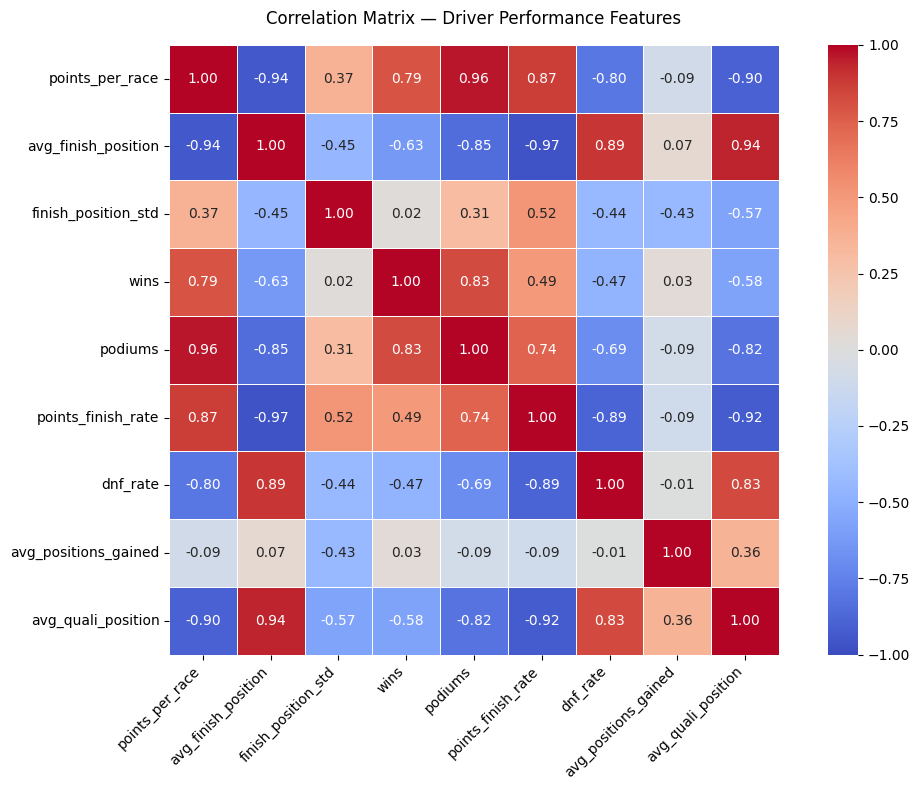

In [21]:
feature_cols = [
    'points_per_race',
    'avg_finish_position',
    'finish_position_std',
    'wins',
    'podiums',
    'points_finish_rate',
    'dnf_rate',
    'avg_positions_gained',
    'avg_quali_position'
]

corr = df[feature_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Driver Performance Features', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

## Principal Component Analysis (PCA)

In [22]:
X = df[feature_cols]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

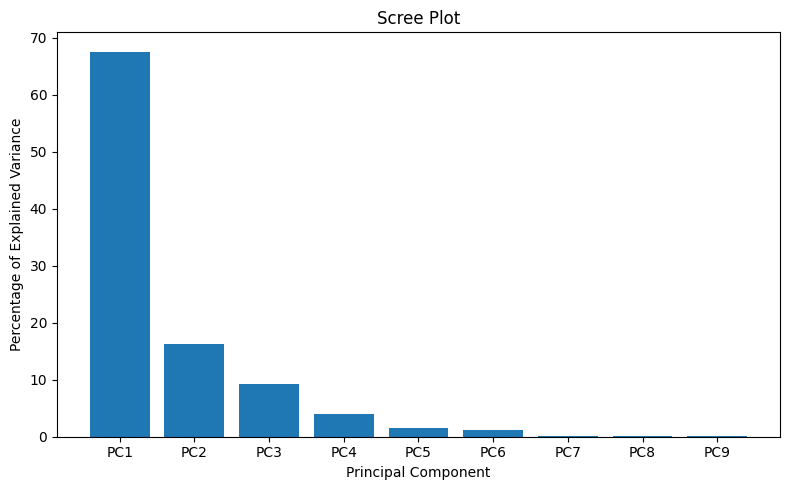

Variance explained per component:
  PC1: 67.6%  (cumulative: 67.6%)
  PC2: 16.2%  (cumulative: 83.8%)
  PC3: 9.2%  (cumulative: 93.0%)
  PC4: 4.0%  (cumulative: 97.0%)
  PC5: 1.5%  (cumulative: 98.5%)
  PC6: 1.1%  (cumulative: 99.6%)
  PC7: 0.2%  (cumulative: 99.8%)
  PC8: 0.1%  (cumulative: 99.9%)
  PC9: 0.1%  (cumulative: 100.0%)


In [23]:
pca     = PCA()
X_pca   = pca.fit_transform(X_scaled)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels  = ['PC' + str(i) for i in range(1, len(per_var) + 1)]

plt.figure(figsize=(8, 5))
plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scree_plot.png', dpi=150)
plt.show()

print("Variance explained per component:")
cumulative = 0
for label, var in zip(labels, per_var):
    cumulative += var
    print(f"  {label}: {var}%  (cumulative: {cumulative:.1f}%)")

### Interpretation

PC1 captures 67.6% of the total variance in the dataset meaning that a 
single underlying dimension explains the majority of differences between 
driver-season performances. PC1 and PC2 together explain 83.8%, which means 
two components capture most of what is happening across all nine features.

The clear elbow after PC2 in the scree plot confirms that additional components 
add very little explanatory value. This level of concentration in PC1 is a direct 
consequence of the high correlations seen in the heatmap points_per_race, 
podiums, avg_finish_position and avg_quali_position are all measuring variations 
of the same underlying concept: how competitive a driver was that season. PCA 
has collapsed that redundancy into a single dominant component.

PC2 capturing 16.2% likely represents a secondary dimension, something that 
varies independently of overall competitiveness. The PC1 loading scores in the 
next cell will show exactly which features drive each component.

## PC1 Loading Scores


PC1 loading scores (sorted by absolute value):
avg_finish_position     0.396
points_per_race         0.395
avg_quali_position      0.390
points_finish_rate      0.380
podiums                 0.368
dnf_rate                0.356
wins                    0.285
finish_position_std     0.205
avg_positions_gained    0.069
dtype: float64


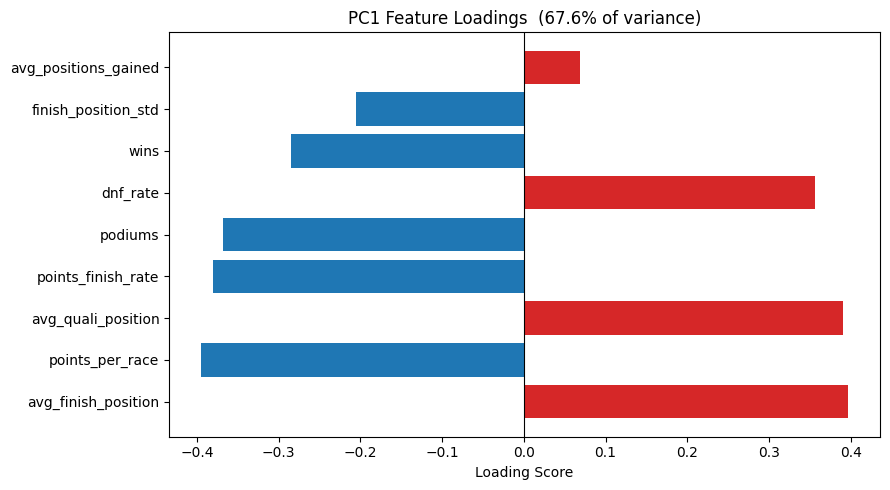

In [24]:
loading_scores = pd.Series(pca.components_[0], index=feature_cols)
loading_scores_sorted = loading_scores.abs().sort_values(ascending=False)

print("PC1 loading scores (sorted by absolute value):")
print(loading_scores_sorted.round(3))

colors = ['#d62728' if loading_scores[f] > 0 else '#1f77b4'
          for f in loading_scores_sorted.index]

plt.figure(figsize=(9, 5))
plt.barh(loading_scores_sorted.index,
         loading_scores[loading_scores_sorted.index],
         color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'PC1 Feature Loadings  ({per_var[0]}% of variance)')
plt.xlabel('Loading Score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pc1_loadings.png', dpi=150)
plt.show()

### Interpretation

PC1 is clearly a general competitiveness axis. The five highest loading 
features, avg_finish_position, points_per_race, avg_quali_position, 
points_finish_rate and podiums, all measure how often a driver finished 
near the front. The direction of the loadings also makes sense: 
avg_finish_position and avg_quali_position load positively because higher 
position numbers mean worse performance, while points_per_race and podiums 
load negatively because higher values mean better performance.

The most important finding here is avg_positions_gained loading at just 0.069. 
This confirms what the correlation heatmap showed , racecraft is a genuinely 
separate dimension that is not captured by overall competitiveness. A driver 
can gain positions consistently without ever challenging for wins, and PC1 
cannot see that. This justifies keeping avg_positions_gained in the index 
as an independent contributor.

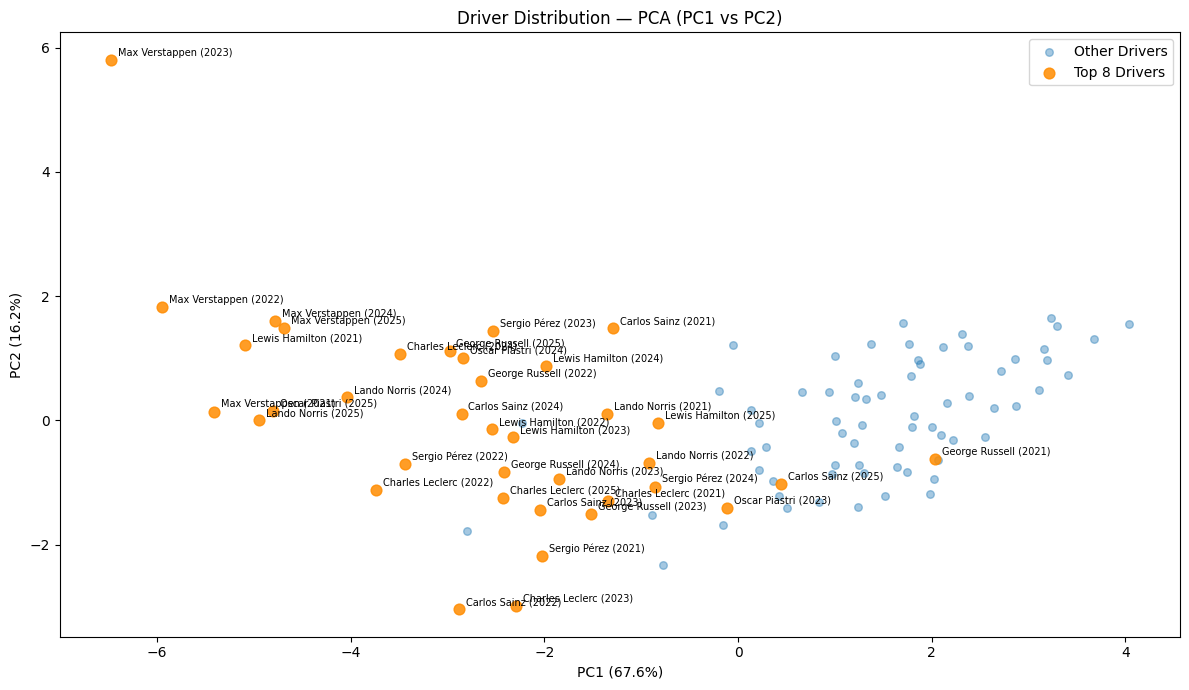

In [25]:
pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['driver_name'] = df['driver_name'].values
pca_df['season']      = df['season'].values

# Label only top drivers by points_per_race
top_drivers = (
    df.sort_values('points_per_race', ascending=False)
    ['driver_name'].unique()[:8]
)
pca_df['is_top'] = pca_df['driver_name'].isin(top_drivers)

fig, ax = plt.subplots(figsize=(12, 7))

others = pca_df[~pca_df['is_top']]
tops   = pca_df[pca_df['is_top']]

ax.scatter(others['PC1'], others['PC2'],
           alpha=0.4, s=30, label='Other Drivers')
ax.scatter(tops['PC1'], tops['PC2'],
           alpha=0.85, s=60, color='darkorange', label='Top 8 Drivers')

for _, row in tops.iterrows():
    ax.annotate(
        f"{row['driver_name']} ({int(row['season'])})",
        (row['PC1'], row['PC2']),
        xytext=(5, 3), textcoords='offset points', fontsize=7
    )

ax.set_title('Driver Distribution — PCA (PC1 vs PC2)')
ax.set_xlabel(f'PC1 ({per_var[0]}%)')
ax.set_ylabel(f'PC2 ({per_var[1]}%)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_scatter.png', dpi=150)
plt.show()

## K-Means Clustering

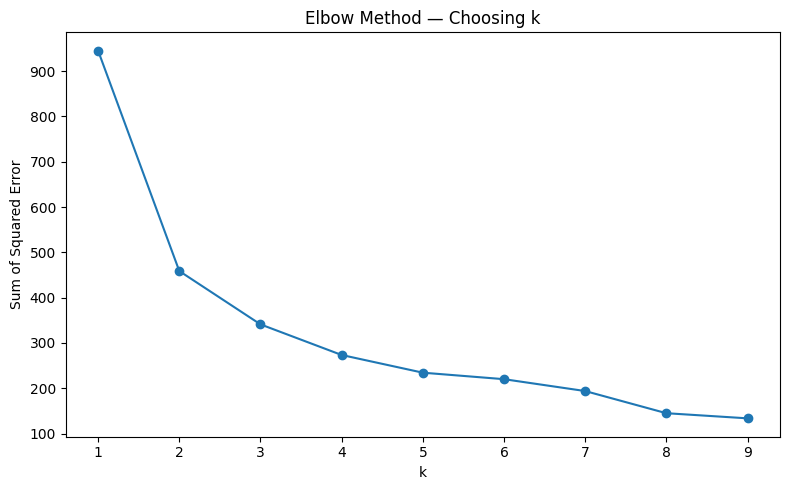

In [ ]:
sse     = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('k')
plt.ylabel('Sum of Squared Error')
plt.title('Elbow Method - Choosing k')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'elbow_plot.png', dpi=150)
plt.show()

### Interpretation

The elbow plot shows the clearest change in gradient between k=2 and k=3, 
after which the curve flattens gradually. K=3 is selected as it aligns with 
the natural competitive structure of Formula 1 elite front runners, 
midfield drivers, and lower grid drivers. Adding more clusters beyond 3 
would split existing groups rather than identify genuinely distinct tiers.

In [27]:
km       = KMeans(n_clusters=3, n_init='auto', random_state=42)
clusters = km.fit_predict(X_scaled)
df['cluster'] = clusters

cluster_means  = df.groupby('cluster')['points_per_race'].mean().sort_values()
cluster_labels = {
    cluster_means.index[0]: 'Lower Grid',
    cluster_means.index[1]: 'Midfield',
    cluster_means.index[2]: 'Elite'
}
df['cluster_label'] = df['cluster'].map(cluster_labels)

print("Cluster mean points per race:")
print(df.groupby('cluster_label')['points_per_race'].mean().round(2))
print("\nCluster sizes:")
print(df['cluster_label'].value_counts())

Cluster mean points per race:
cluster_label
Elite         17.20
Lower Grid     1.13
Midfield       8.53
Name: points_per_race, dtype: float64

Cluster sizes:
cluster_label
Lower Grid    64
Midfield      31
Elite         10
Name: count, dtype: int64


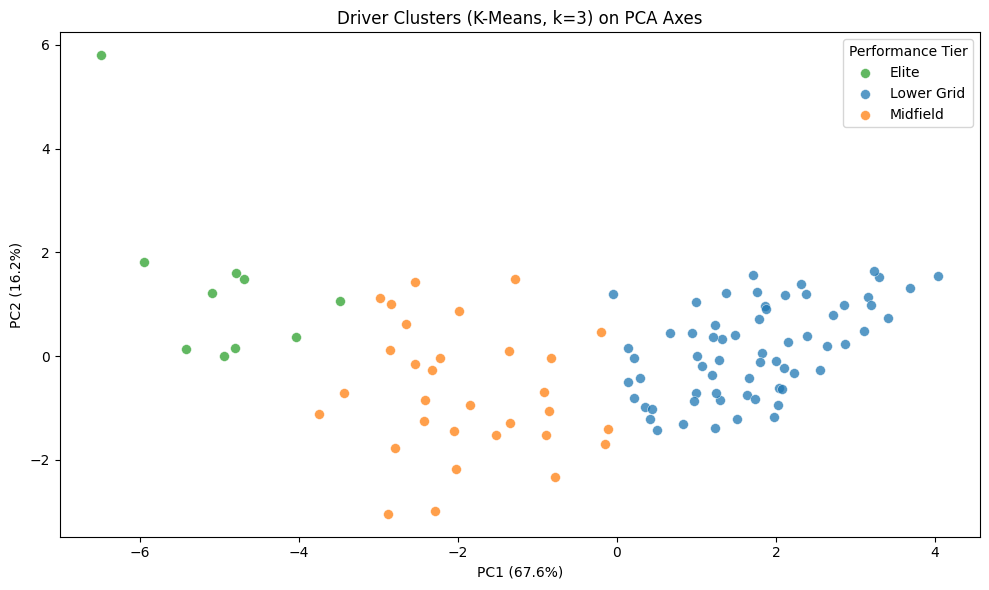

In [28]:
colour_map = {'Elite': '#2ca02c', 'Midfield': '#ff7f0e', 'Lower Grid': '#1f77b4'}

fig, ax = plt.subplots(figsize=(10, 6))

for label, group in df.groupby('cluster_label'):
    idx = group.index
    ax.scatter(
        X_pca[idx, 0], X_pca[idx, 1],
        label=label,
        color=colour_map[label],
        alpha=0.75, s=50,
        edgecolors='white', linewidths=0.4
    )

ax.set_title('Driver Clusters (K-Means, k=3) on PCA Axes')
ax.set_xlabel(f'PC1 ({per_var[0]}%)')
ax.set_ylabel(f'PC2 ({per_var[1]}%)')
ax.legend(title='Performance Tier')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_scatter.png', dpi=150)
plt.show()